**Neural Network**

1. What is Deep Learning? Briefly describe how it evolved and how it differs
from traditional machine learning.
   - Deep Learning is a subset of Machine Learning that uses artificial neural networks with multiple layers (deep architectures) to learn patterns from data.

It evolved from traditional machine learning due to:

Increase in data availability (Big Data)
High computational power (GPUs)
Improved algorithms

Difference from Traditional ML:

Traditional ML requires manual feature extraction
Deep Learning automatically learns features
Deep Learning performs better on large datasets

2. Explain the basic architecture and functioning of a Perceptron. What are its
limitations?
   - A Perceptron is the simplest type of neural network.

Structure:

Input layer
Weights
Bias
Activation function

Working:
Output = Activation (Weighted sum of inputs + Bias)

Limitations:

Cannot solve non-linear problems (like XOR)
Only binary classification
Limited learning capability

3.  Describe the purpose of activation function in neural networks. Compare
Sigmoid, ReLU, and Tanh functions.
    - | Function | Range  | Advantage       | Disadvantage       |
| -------- | ------ | --------------- | ------------------ |
| Sigmoid  | (0,1)  | Smooth          | Vanishing gradient |
| ReLU     | (0,∞)  | Fast, efficient | Dead neurons       |
| Tanh     | (-1,1) | Zero-centered   | Vanishing gradient |

4. What is the difference between Loss function and Cost function in neural
networks? Provide examples.
   - Loss Function: Error for a single data point
Cost Function: Average error over dataset

Examples:

Loss: Binary Crossentropy
Cost: Mean Squared Error (MSE)

5. What is the role of optimizers in neural networks? Compare Gradient
Descent, Adam, and RMSprop.
   - | Optimizer        | Feature        |
| ---------------- | -------------- |
| Gradient Descent | Basic, slow    |
| Adam             | Fast, adaptive |
| RMSprop          | Good for RNN   |




In [1]:
#6. Write a Python program to implement a single-layer perceptron from scratch using NumPy to solve the logical AND gate.
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])

weights = np.zeros(2)
bias = 0
lr = 0.1

for epoch in range(10):
    for i in range(len(X)):
        linear = np.dot(X[i], weights) + bias
        output = 1 if linear > 0 else 0
        error = y[i] - output

        weights += lr * error * X[i]
        bias += lr * error

print("Weights:", weights)
print("Bias:", bias)

for i in range(len(X)):
    linear = np.dot(X[i], weights) + bias
    output = 1 if linear > 0 else 0
    print(X[i], "->", output)


Weights: [0.2 0.1]
Bias: -0.2
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


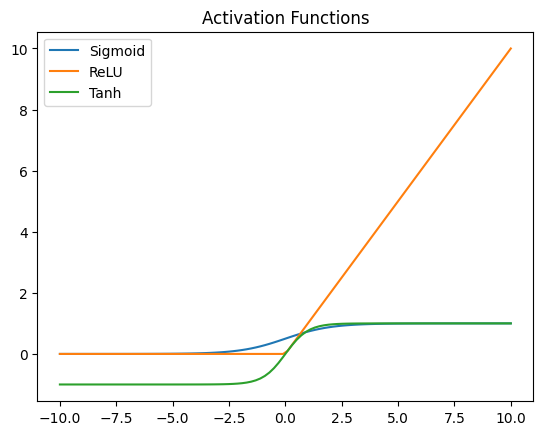

In [2]:
#7. Implement and visualize Sigmoid, ReLU, and Tanh activation functions using Matplotlib.
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)

sigmoid = 1/(1+np.exp(-x))
relu = np.maximum(0, x)
tanh = np.tanh(x)

plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, relu, label="ReLU")
plt.plot(x, tanh, label="Tanh")

plt.legend()
plt.title("Activation Functions")
plt.show()

In [3]:
#8. Use Keras to build and train a simple multilayer neural network on the MNIST digits dataset. Print the training accuracy.
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

(X_train, y_train), (X_test, y_test) = mnist.load_data()

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=3)

loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8582 - loss: 2.5267
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9132 - loss: 0.3808
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9301 - loss: 0.2828
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9151 - loss: 0.3784
Accuracy: 0.9150999784469604


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6857 - loss: 3.4869 - val_accuracy: 0.6850 - val_loss: 0.9131
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7351 - loss: 0.7625 - val_accuracy: 0.7334 - val_loss: 0.8287
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7685 - loss: 0.6585 - val_accuracy: 0.7794 - val_loss: 0.6658
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7829 - loss: 0.6076 - val_accuracy: 0.7916 - val_loss: 0.6287
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7913 - loss: 0.5860 - val_accuracy: 0.7874 - val_loss: 0.6151


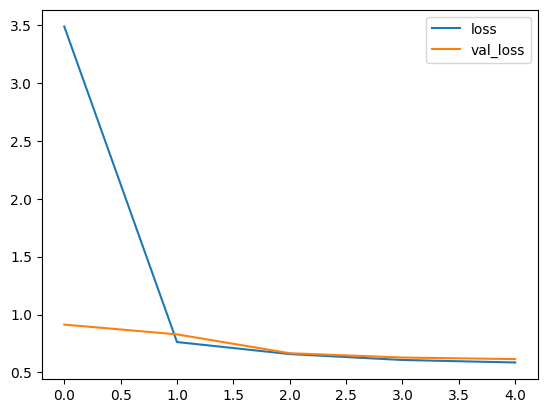

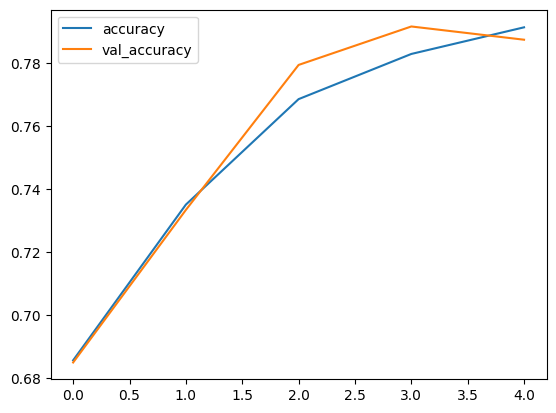

In [4]:
#9. Visualize the loss and accuracy curves for a neural network model trained on the Fashion MNIST dataset. Interpret the training behavior.
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

In [6]:
#10.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(10,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Model ready for training...")

Model ready for training...


10. You are working on a project for a bank that wants to automatically detect
fraudulent transactions. The dataset is large, imbalanced, and contains structured features like transaction amount, merchant ID, and customer location. The goal is to classify each transaction as fraudulent or legitimate.
    - Use Multilayer Neural Network
Activation: ReLU (hidden), Sigmoid (output)
Loss: Binary Crossentropy
Handle imbalance using:
Class weights
SMOTE
Optimizer: Adam
Prevent overfitting:
Dropout
Early stopping
